In [1]:
import os
from pathlib import Path
import glob

import tables as tb
import numpy  as np
import pandas as pd

from collections import defaultdict

from scipy import interpolate
from scipy.interpolate import UnivariateSpline
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [2]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';

In [3]:
import invisible_cities.io.pmaps_io as pmapio
import invisible_cities.io.dst_io  as dstio
import invisible_cities.io.mcinfo_io as mcio
import gres.database.load_db as db
import invisible_cities.io.run_and_event_io as rio

import invisible_cities.core.core_functions as coref

from lmfit.models import GaussianModel, LinearModel, ExponentialModel, ConstantModel

In [4]:
nfiles = 100000
datatypes = ['22Na', '83mKr', '133Ba', 'NoSource', '57Co', '241Am', '55Fe', 'Needle']#[2]

In [5]:
#Params

fano = 0.15 #0.23
wi   = 21.61
#26.4 #common value with previous measurment for argon
#26.27 #argon
#21.61 #xenon


ws   = 40
dist = 1.02 #cm

wi_kev     = wi/1e3
#22, 235, 620, 701, 1073, 2453


data_pmt = db.DataPMT('gap', 5000)
print(data_pmt)
pmt_sigma = (data_pmt.Sigma/data_pmt.adc_to_pes).mean()
print(pmt_sigma)

def get_el_yield(pressure, voltage, d=1):
    lyield = (81*voltage/pressure/d - 47)*pressure*d
    lyield = np.where(lyield > 0, lyield, 0)
    return lyield 


def get_el_yield_new(pressure, voltage, d=1):
    new_volt = voltage - (1.1-0.58)
    return (81*new_volt/pressure/d - 47)*pressure*d


def get_intrinsic_resolution(energy, fano, wi, det_phot, pmt_sigma):
    fano_term =  fano / (energy/wi)
    det_term  = (1+pmt_sigma**2)/det_phot
    return 235 * np.sqrt(fano_term + det_term)



   SensorID  ChannelID PmtID  Active       X       Y  coeff_blr  coeff_c  \
0         0          0   PMT       1   0.000   0.000          0        0   
1         1          1   PMT       1  36.253   2.949          0        0   
2         2          2   PMT       1 -15.573 -32.871          0        0   
3         3          3   PMT       1 -20.680  29.922          0        0   
4         4          4   PMT       1  20.680 -29.922          0        0   
5         5          5   PMT       1 -36.253  -2.949          0        0   
6         6          6   PMT       1  15.573  32.871          0        0   

   adc_to_pes  noise_rms  Sigma  
0       11.04          0   3.87  
1        9.54          0   4.61  
2        6.05          0   6.15  
3       14.51          0   5.14  
4       14.31          0   6.70  
5       11.41          0   5.56  
6       17.77          0   6.03  
0.499910176213601


### Load data

In [7]:
# LIGHT TUBE
print(datatypes[6])
pressure   = 8.5
delta_volt = 5
source     = datatypes[6]
gas        = 'Wire'

#xenon
#all_runs = ([[2541],[2540], [2539], [2538], [2537], [2536], [2535], [2525], [2526], [2527], [2528], [2529], [2530], [2531], [2532], [2533], [2534]])
#all_runs = ([[2543], [2544], [2545], [2546], [2547], [2548], [2549], [2550], [2551], [2552], [2553], [2554], [2555], [2556], [2557], [2558]])
#all_runs = ([[2561], [2562], [2563], [2564], [2565], [2566], [2567], [2568], [2569], [2570], [2571]])
#all_runs = ([[2585], [2586], [2587], [2588], [2589], [2590], [2591] ,[2592], [2593], [2594] ,[2595], [2596], [2597], [2598], [2599], [2602]])
#all_runs = ([[2605], [2606], [2607], [2608], [2609], [2610], [2611], [2612], [2613], [2614], [2615], [2616], [2617], [2618], [2619], [2620], [2621]])
#all_runs = ([[2622], [2623], [2624], [2625], [2626], [2627], [2628], [2629], [2630], [2631], [2632], [2633], [2634], [2635]])
all_runs = ([[2649], [2650], [2651], [2652], [2653], [2654], [2655], [2656], [2657], [2658], [2659], [2660]])

#xenon
#el_volts = np.array([6.1, 5.8, 5.5, 5.2, 4.9, 4.6, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8, 2.5, 2.2, 1.9, 1.6, 1.3])
#el_volts = np.array([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5])
#el_volts = np.array([2.5, 3.3, 4.1, 4.9, 5.7, 6.5, 7.3, 8.1, 8.9, 9.7, 10.5])
#el_volts = np.array([2.9, 3.9, 4.9, 5.9, 6.9, 7.9, 8.9, 9.9, 10.9, 11.9, 12.9, 13.9, 14.9, 15.9, 16.9, 18.9])
#el_volts = np.array([3.5, 4.7, 5.9, 7.1, 8.3, 9.5, 10.7, 11.9, 13.1, 14.3, 15.5, 16.7, 17.9, 19.1, 20.3, 21.5, 22])
#el_volts = np.array([4, 5.4, 6.8, 8.2, 9.6, 11.0, 12.4, 13.8, 15.2, 16.6, 18.0, 19.4, 20.8, 22.2])
el_volts = np.array([4.4, 6.1, 7.8, 9.5, 11.2, 12.9, 14.6, 16.3, 18., 19.7, 21.4, 23.1])




labels   = [f'{el_volt:.2f} kV' for el_volt in el_volts] 

datasets_s1 = []
datasets_s2 = []

dst_path = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/EL_yield_dst.h5'

for run_numbers in all_runs:    
    data_1_s1 = []
    data_1_s2 = [] 
    print(run_numbers)
    for run_number in run_numbers:
        print(run_number)
        inpath = f'/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R{run_number}/octavia/'
        data_1_s1.append(pd.read_hdf(inpath+f'DST_run_{run_number}_pmaps.h5', 'S1'))
        data_1_s2.append(pd.read_hdf(inpath+f'DST_run_{run_number}_pmaps.h5', 'WVF'))
    
    data_1_s1 = pd.concat(data_1_s1).reset_index(drop=True)    
    data_1_s2 = pd.concat(data_1_s2).reset_index(drop=True)    
    #print(data_1_s2)
    data_1_s1['r'] = np.sqrt(data_1_s1.x**2 + data_1_s1.y**2)
    data_1_s2['r'] = np.sqrt(data_1_s2.x**2 + data_1_s2.y**2)
    datasets_s1.append(data_1_s1)
    datasets_s2.append(data_1_s2)
print("datasets_s2 is:", datasets_s2)



55Fe
[2649]
2649
[2650]
2650
[2651]
2651
[2652]
2652
[2653]
2653
[2654]
2654
[2655]
2655
[2656]
2656
[2657]
2657
[2658]
2658
[2659]
2659
[2660]
2660
datasets_s2 is: [        event     timestamp            x            y            r     energy  \
0           0       1464655   -68.042076    55.956632    88.095793   8.492605   
1           3       1480527   184.206145  -147.477170   235.969107   2.923518   
2           4       1502419   -36.306936   -92.741763    99.595322 -25.513470   
3           5       1530002     2.725838   -31.904718    32.020950 -43.610921   
4           7       1541720   497.834827   132.274401   515.107787  -1.691438   
...       ...           ...          ...          ...          ...        ...   
31711  364813  124698938751    83.922651     9.769150    84.489334 -20.032506   
31712  364814  124700334714   208.734559  -748.499618   777.059711   0.478941   
31713  364815  124700383945    14.561693    -0.143793    14.562403  64.202452   
31714  364816  124700414

In [8]:
print(len(all_runs), len(el_volts))

12 12


In [9]:
el_volts

array([ 4.4,  6.1,  7.8,  9.5, 11.2, 12.9, 14.6, 16.3, 18. , 19.7, 21.4,
       23.1])

### Look at data

escale 1 is :  13.976271186440679
escale 1 is :  13.976271186440679
escale 1 is :  31.48813559322034
escale 1 is :  100.70169491525425
escale 1 is :  191.59661016949153
escale 1 is :  286.6610169491525
escale 1 is :  385.8949152542372
escale 1 is :  475.122033898305
escale 1 is :  483.89830508474574
escale 1 is :  565.2542372881355
escale 1 is :  661.864406779661
escale 1 is :  770.3389830508474


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_59204/1560137757.py:141: RankWarning: Polyfit may be poorly conditioned
  pars = mod.guess(yfit, x=xfit)
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_59204/1560137757.py:141: RankWarning: Polyfit may be poorly conditioned
  pars = mod.guess(yfit, x=xfit)
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
 

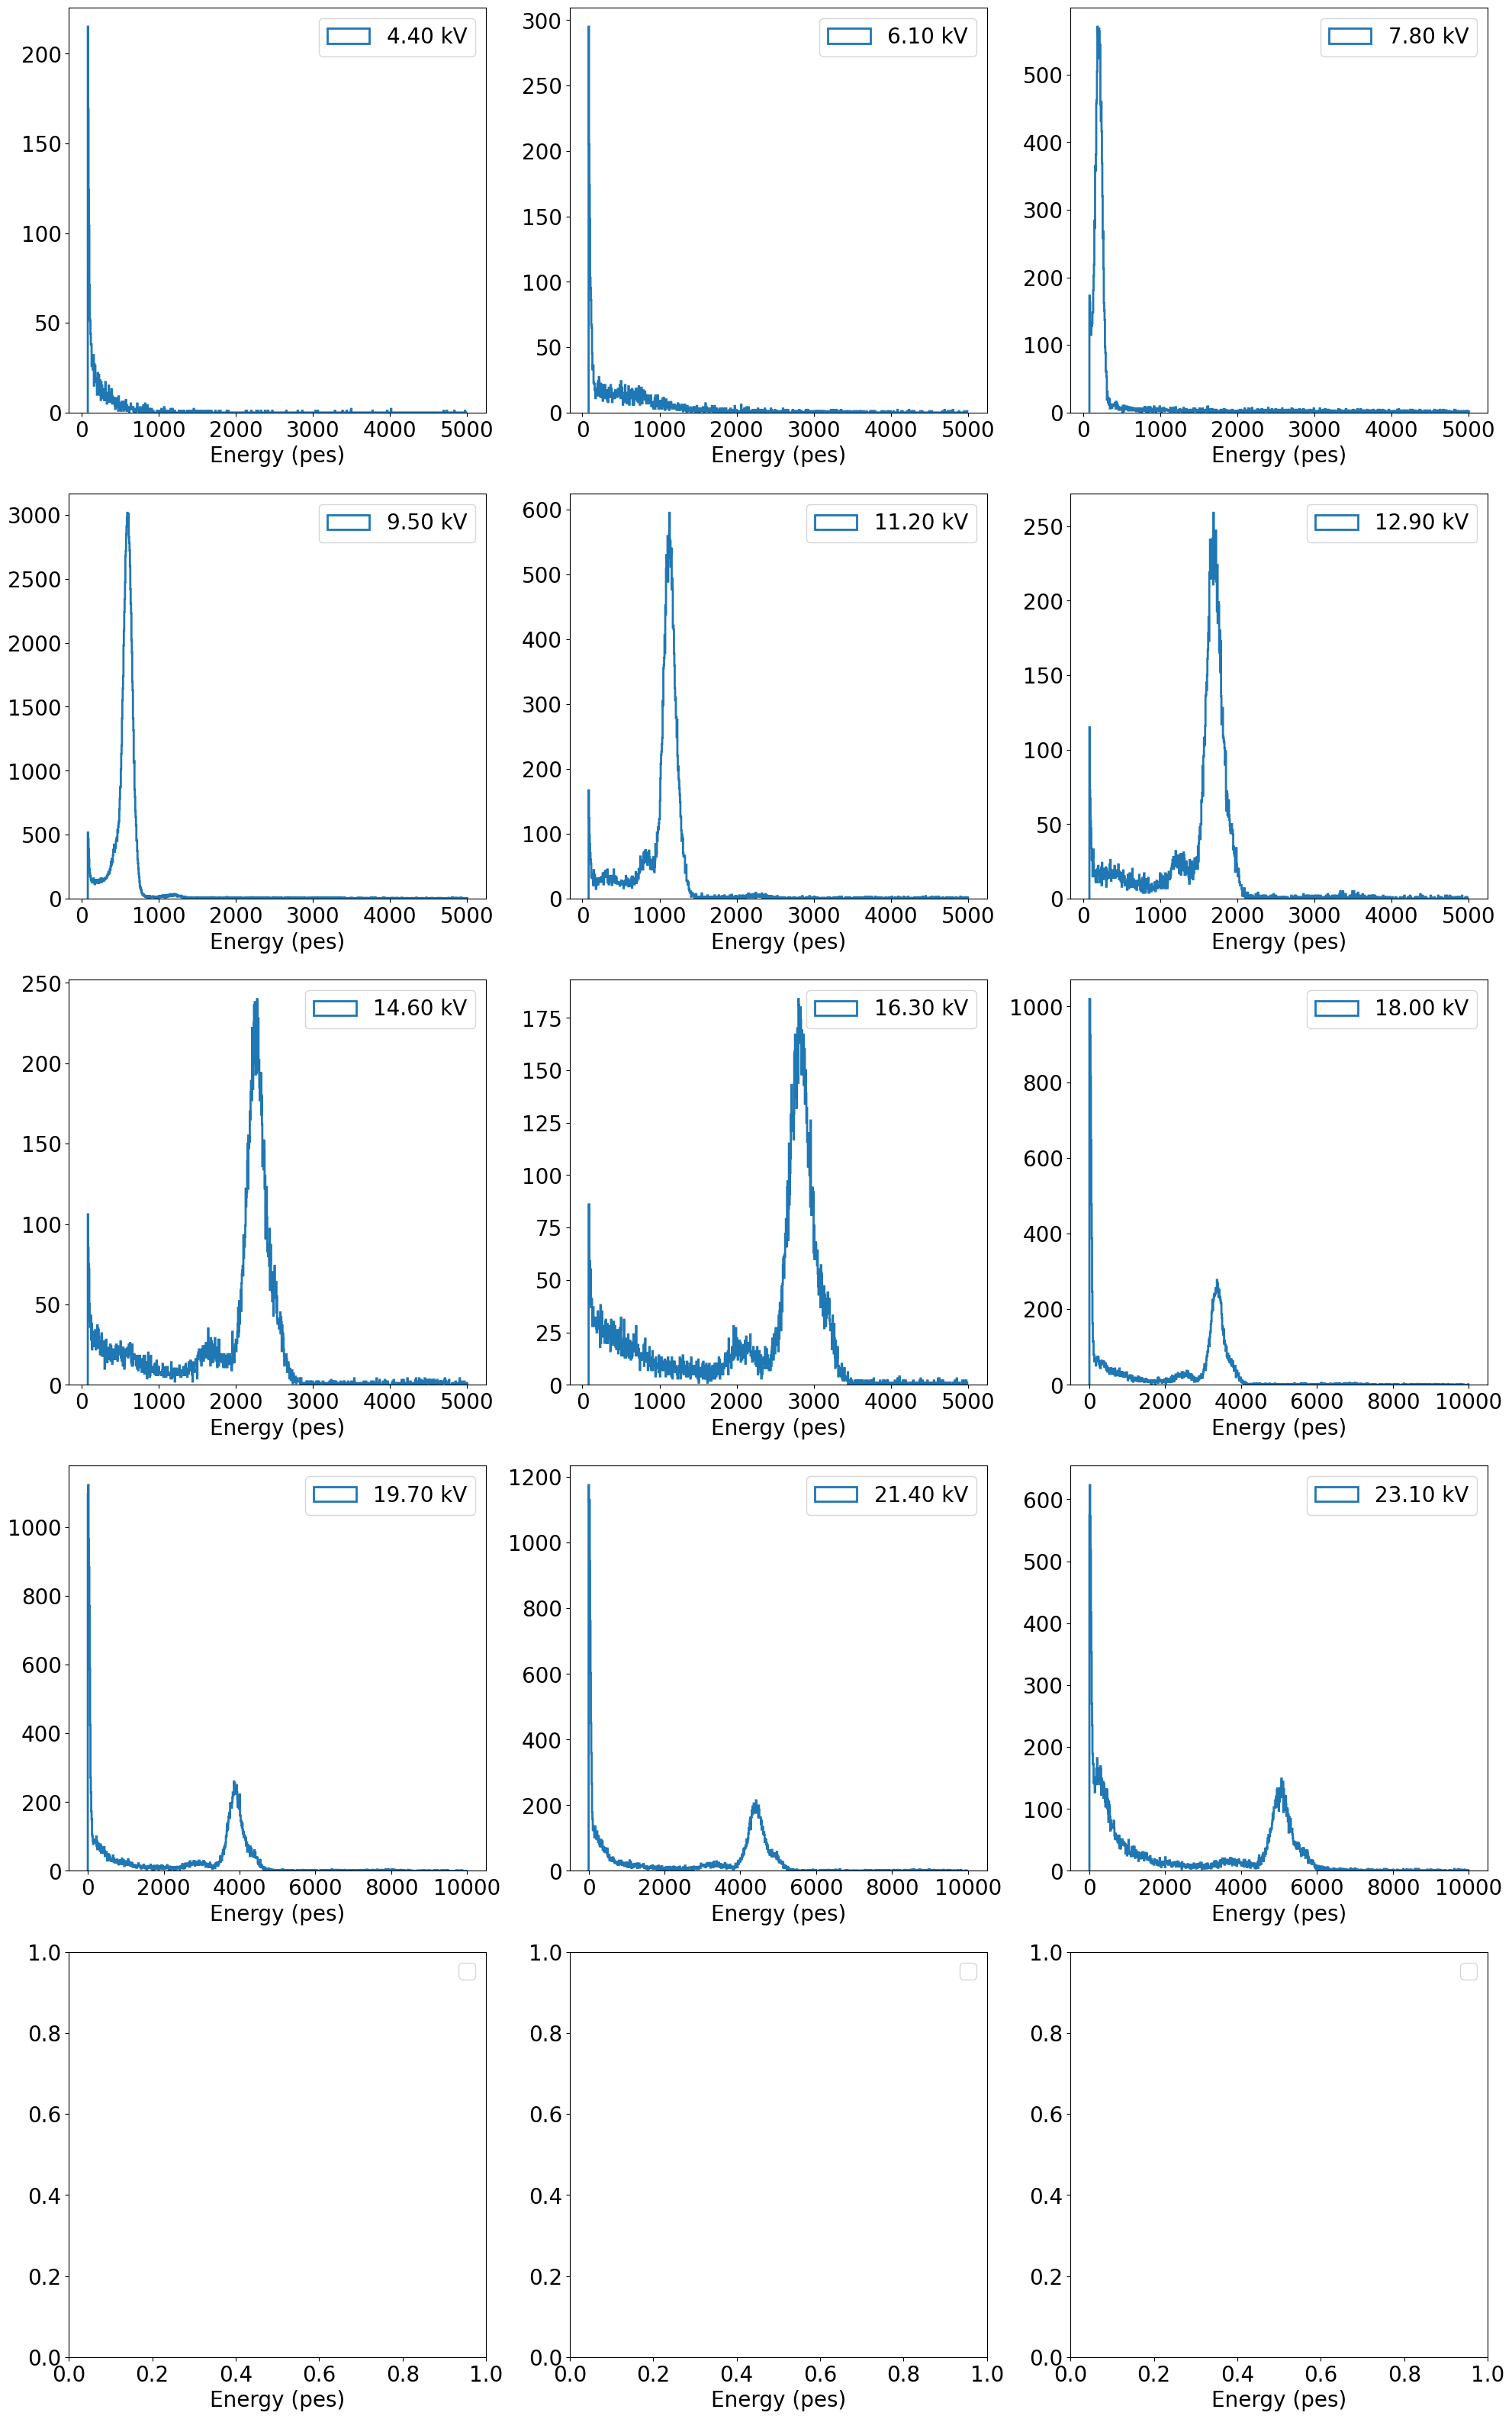

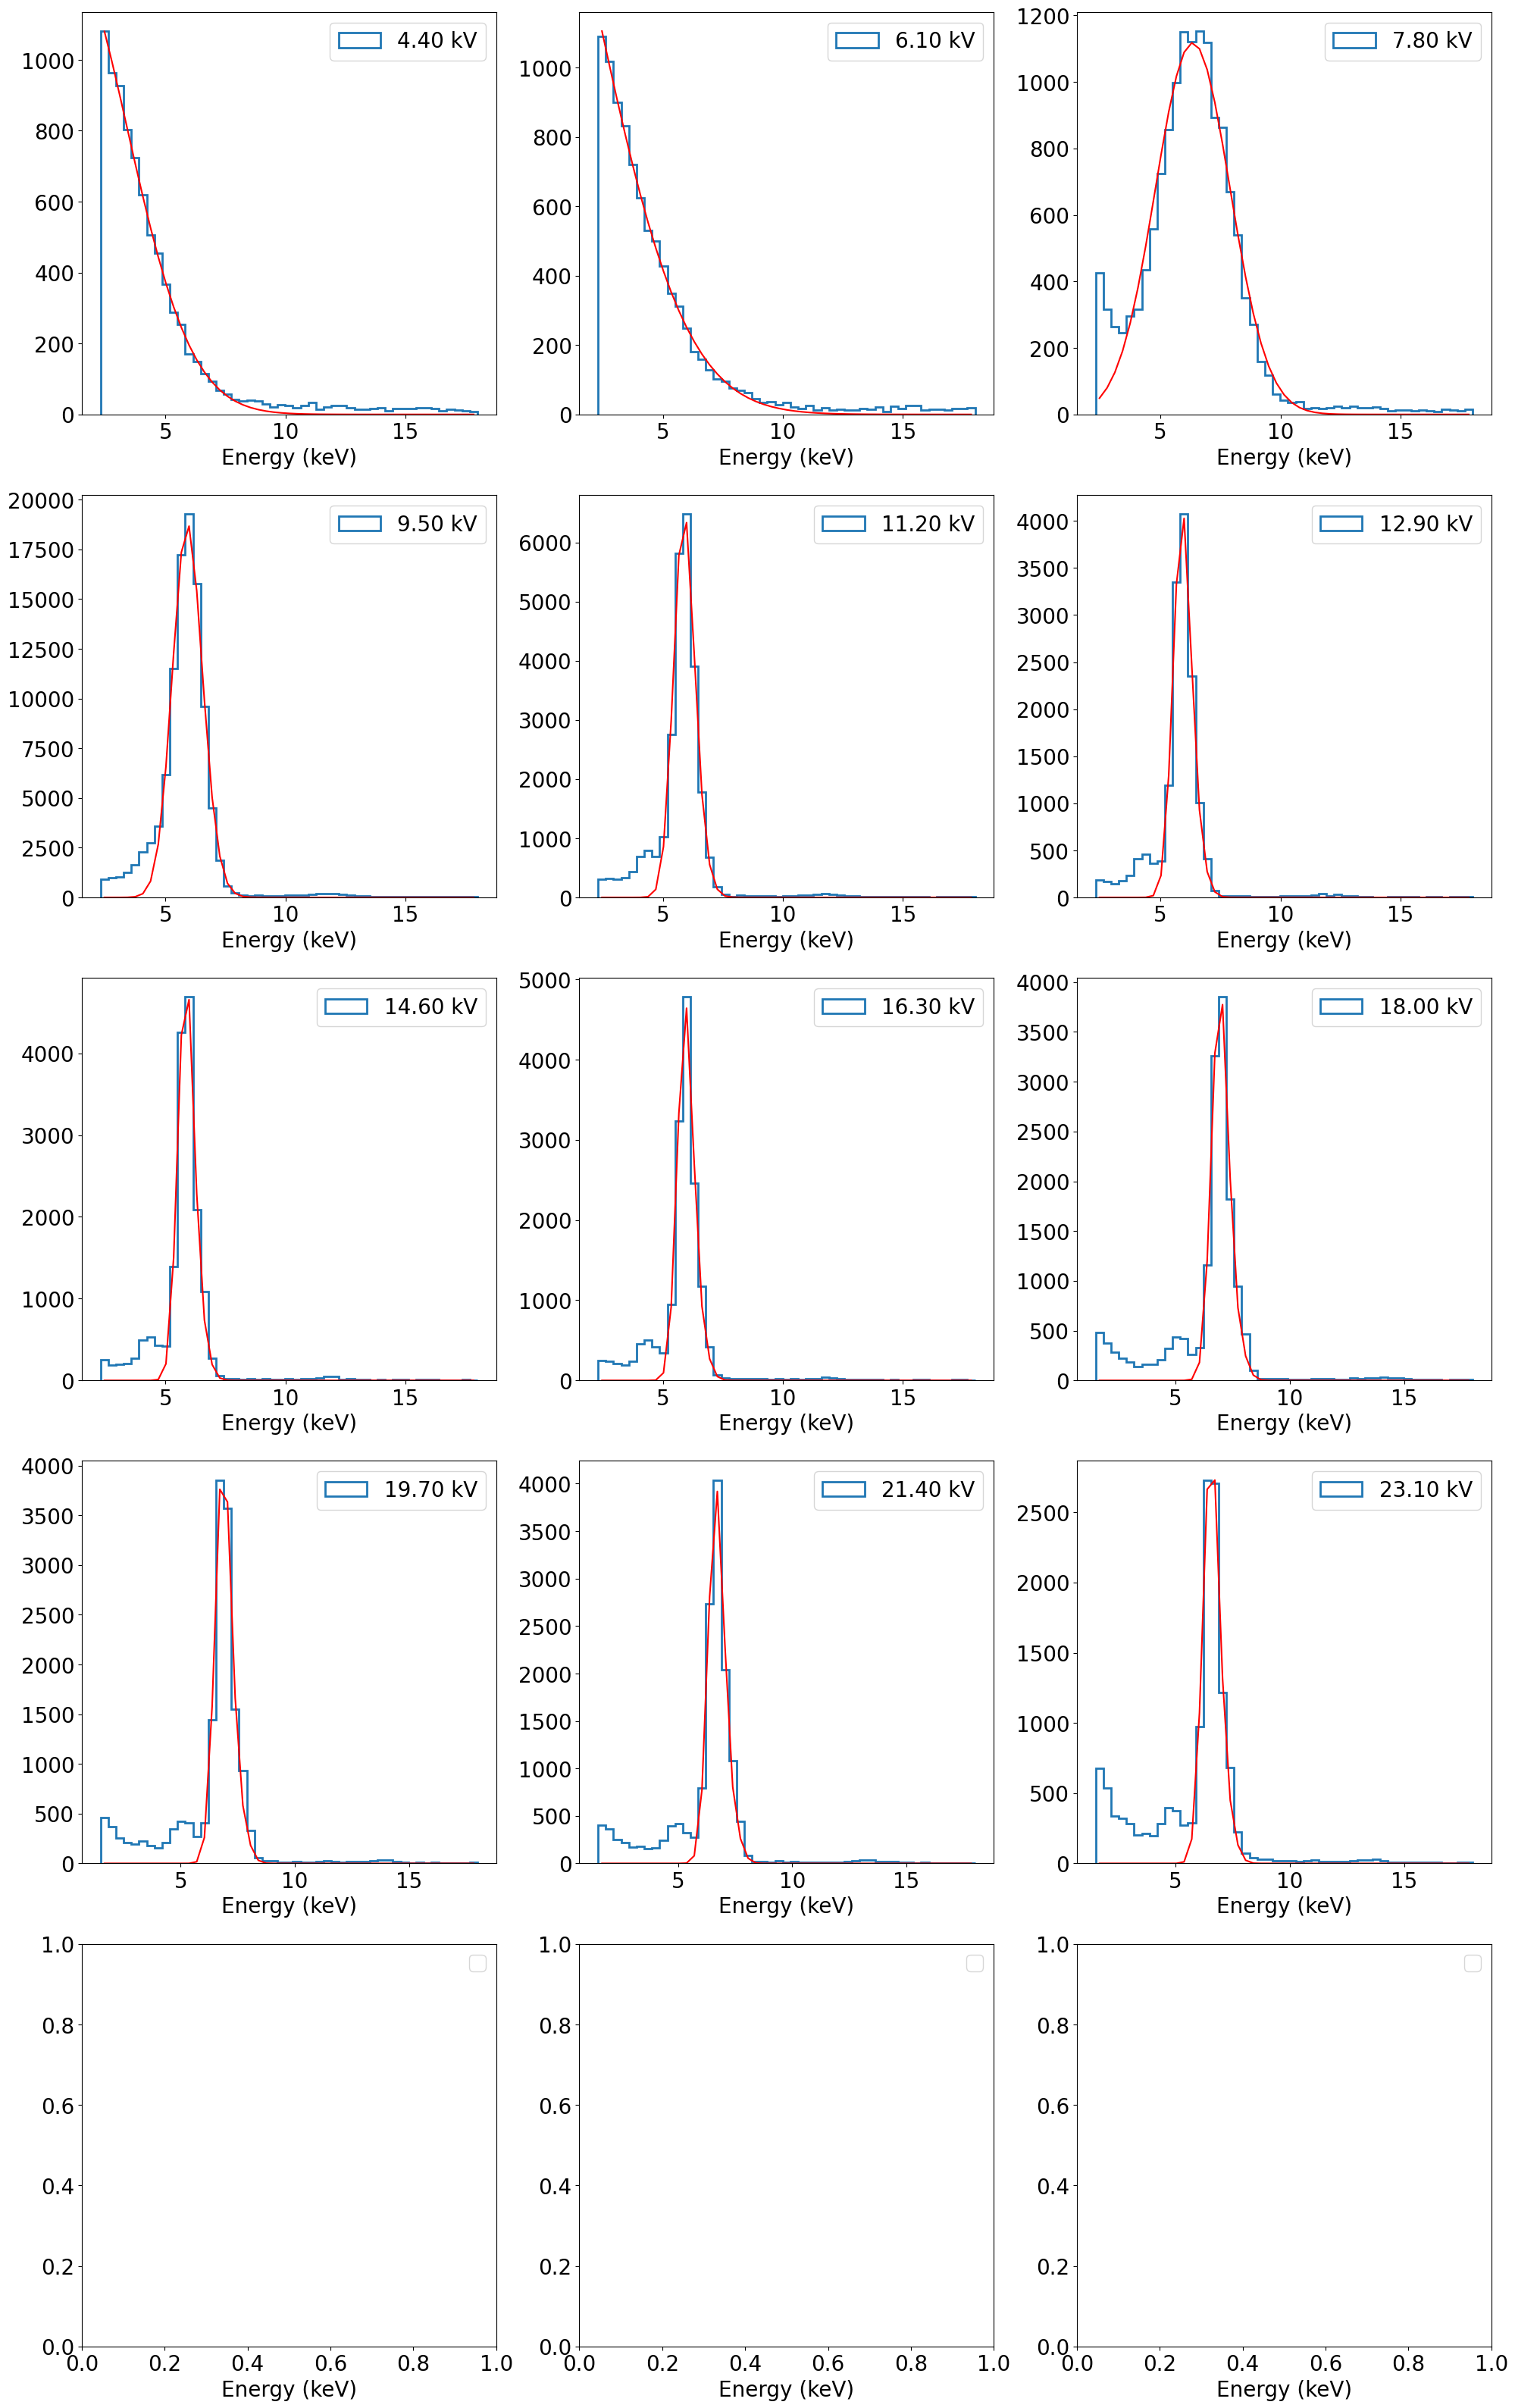

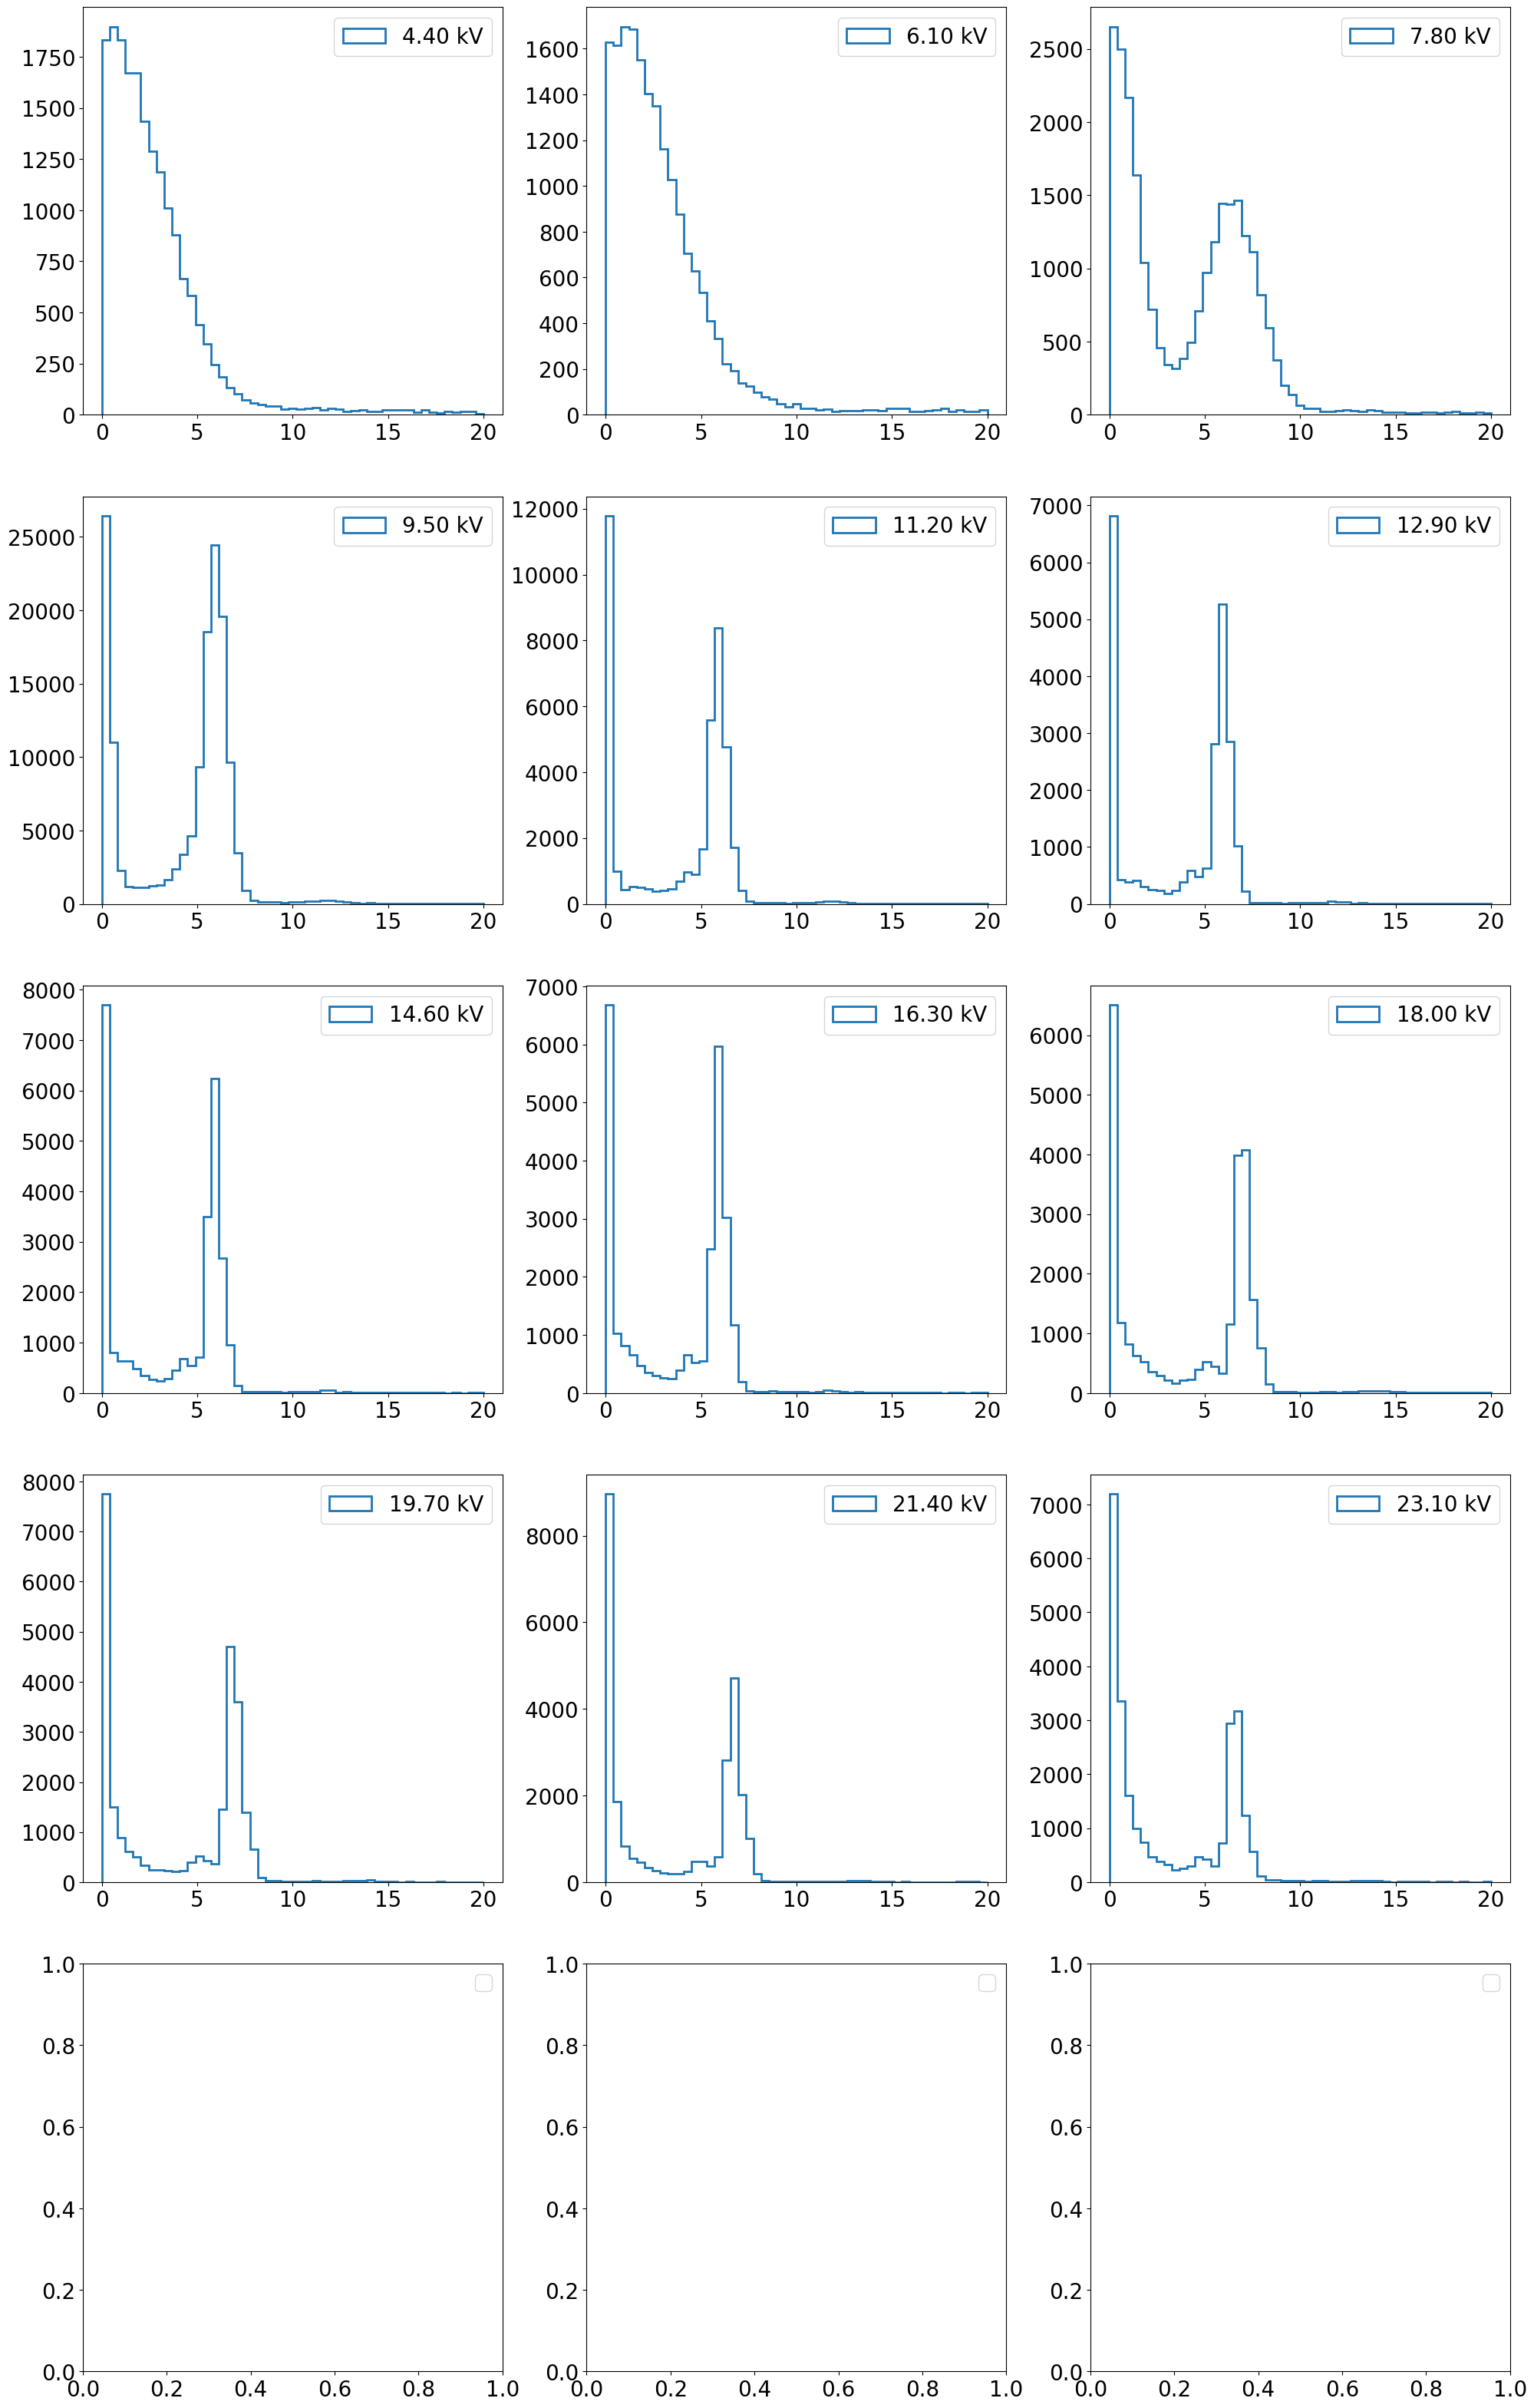

In [10]:
nrows     = len(el_volts)//3 + 1
fig_e, axes_e = plt.subplots(nrows, 3, figsize=(24, 8*nrows))
fig_c, axes_c = plt.subplots(nrows, 3, figsize=(24, 8*nrows))
fig_t, axes_t = plt.subplots(nrows, 3, figsize=(24, 8*nrows))

axes_e = axes_e.flatten()
axes_c = axes_c.flatten()
axes_t = axes_t.flatten()

ratio     = np.where(el_volts<8, el_volts/np.max(el_volts)**2, el_volts/np.max(el_volts))
enebins_c = np.linspace(2.3, 18, 50)
enebins_t = np.linspace(-0, 20, 50)
#enebins_t = np.linspace(0., 20, 100)

normed = False
var    = 'energy'

eref_kev  = 5.9
ene_source = 5.9e3

erange    = [2000, 6000]
sels_e_1  = []
nsigma    = 3
eref      = 500
sigma_ref = 150/nsigma

centers   = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

mus, sigmas = [], []
thr_decay   = []

enebins = np.linspace(80, 5000, 1001)

n_ie       = ene_source/wi

### Fit
thresh_light = False
for jj, data_1_s2, label_1 in zip(range(len(labels)), datasets_s2, labels):
    #if label_1 !='7.5 kV': continue
    #enebins   = np.linspace(00, 2000, 201) if el_volts[jj]<8 else np.linspace(500, 5000, 201)
    if (thresh_light == True):
        enebins_c = np.linspace(1.5, 18, 50)
        enebins = np.linspace(0, 10000, 1001)
        y,x, *_ = axes_e[jj].hist(data_1_s2[var], enebins, histtype='step', 
             lw=2, label=label_1); #show the energy peaks in pes
        x = coref.shift_to_bin_centers(x) #adjust bins

        ### Uncomment if wf not found and put enebin_c to ~1 - 1.5
        mask = (x > x[y.argmax()] + 500)

        if (y[mask].argmax() >= 100):
            escale_1 = x[y[mask].argmax()]/eref_kev #adjust axis
        else:
            escale_1 = x[y.argmax()]/eref_kev #adjust axis
    else:
        y,x, *_ = axes_e[jj].hist(data_1_s2[var], enebins, histtype='step', 
             lw=2, label=label_1); #show the energy peaks in pes
        x = coref.shift_to_bin_centers(x) #adjust bins

        ### Uncomment if wf not found and put enebin_c to ~1 - 1.5
        mask = (x > x[y.argmax()] + 50)

        if (y[mask].argmax() >= 30):
            escale_1 = x[y[mask].argmax()]/eref_kev #adjust axis
        else:
            escale_1 = x[y.argmax()]/eref_kev #adjust axis
        
    
    if (escale_1 >= 400):
        thresh_light = True
        
    
        
    
    print("escale 1 is : ", escale_1)
    #escale_1 = x[y.argmax()]/eref_kev ### Comment if not found
    
    data_1_s2['energy_kev'] = data_1_s2[var]/escale_1 #conversion of energy in kev
    new_sigma = sigma_ref * np.sqrt(escale_1) #conversion of the sigma obtained to the good scale
    #print(x[y.argmax()])
    #print(escale_1)
    y,x, *_ = axes_c[jj].hist(data_1_s2[var+'_kev'], enebins_c, histtype='step', 
         lw=2, label=label_1); #show the energy peaks in kev
    x = coref.shift_to_bin_centers(x)
    
    sels_e_1.append(coref.in_range(data_1_s2[var+'_kev'], *erange))

    efit   = [x[y.argmax()] - nsigma * new_sigma, x[y.argmax()] + nsigma * new_sigma]#escale_1 * efit0 * np.sqrt(escale_1)
    #print(efit)
    xd = x.copy()
    yd = y.copy()
    sel_f = coref.in_range(xd, *efit)
    
    #definition of gaussian model and fit applied on the main peaks, storing of the parameters
    mod  = GaussianModel(prefix='g1_')
    pars = mod.guess(yd[sel_f], x=xd[sel_f])
    pars['g1_amplitude'].set(min=0)
    for i in range(1, len(centers)):
        g = GaussianModel(prefix=f'g{i+1}_')
        mod += g
        params = g.make_params(center=pars['g1_center'],
                                sigma=pars['g1_sigma'],
                                amplitude=pars['g1_amplitude'])
        params[f'g{i+1}_center'].set(value=pars['g1_center'], vary=True, expr=f'g1_center*{centers[i]/centers[0]}')
        params[f'g{i+1}_sigma'].set(value=pars['g1_center'], vary=True, expr=f'g1_sigma*{np.sqrt(centers[i]/centers[0])}')
        #params[f'g{i+1}_amplitude'].set(min=0)
        params[f'g{i+1}_amplitude'].set(value=pars['g1_center'], min=0, vary=True, expr=f'g1_amplitude*{int_ratio[i]/int_ratio[0]}')

        pars.update(params)
    
    out = mod.fit(yd[sel_f], pars, x=xd[sel_f])
    
    axes_c[jj].plot(xd[sel_f], out.best_fit, '-', c='r')
    
    result =  out.result.params
    mu     = np.array([result['g1_center'].value, result['g1_center'].stderr])*escale_1/eref_kev
    #print('g1 center is : ', result['g1_center'].value * escale_1)
    #print("mu is : ", mu)
    sigma  = np.array([result['g1_sigma' ].value, result['g1_sigma' ].stderr])*escale_1/eref_kev
    mus.append(mu)
    sigmas.append(sigma)

    reso   = sigma[0]/mu[0] * 235
#    print(f'E resolution ({label_1}) =  {reso:.2f}% ({result["g1_center"].value} pes)')
    #print(f'E resolution ({label_1}) =  {reso:.2f}%')
    #print(f'Intrinsic resolution = {get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)}%')

    #break

    #### Threshold limit
    
    
    y,x, *_ = axes_t[jj].hist(data_1_s2[var+'_kev'], enebins_t, histtype='step', 
         lw=2, label=label_1);
    xt = coref.shift_to_bin_centers(x)
    mod = ExponentialModel(prefix='e1_')
    
    yfit, xfit = y[xt<0.5], xt[xt<0.5]
    yfit -= y[xt>0.5].mean()
    pars = mod.guess(yfit, x=xfit)
    c   = ConstantModel(prefix=f'c1_')
    pars.add('c1_c', value=y[xt>0.8].mean(), min=0)
    mod+=c
    
    try:
        out = mod.fit(yfit, pars, x=xfit)
        axes_t[jj].plot(xfit, out.best_fit+y[xt>0.5].mean(), '-', c='r')
        
        result = out.result.params
        axes_t[jj].axvline(3*result['e1_decay'])
        
        thr_decay.append([3*result['e1_decay'].value, 3*result['e1_decay'].stderr])
        
    except:
        thr_decay.append([0, 0])
    
for ax in axes_e:
    ax.legend(loc=1)
    #ax.set_yscale('log')
    ax.set_xlabel('Energy (pes)')

for ax in axes_c:
    ax.legend(loc=1)
    ax.set_xlabel('Energy (keV)')
    #ax.set_xlim(0, 1)

for ax in axes_t:
    ax.legend(loc=1)
    #ax.set_xlim(0, 1)


ar_xray   = [2.9, 3.2]
colors    = ['b'] * len(ar_xray)
#al_xray   = [1.5]
#colors   += ['k'] * fe_lines
fe_lines  = [5.9, 6.5]
colors   += ['k'] * len(fe_lines)
cu_lines = [9.4]
colors   += ['r'] * len(cu_lines)

am_lines = [13.9, 17.7, 26.3, 59.6][:3] # From 2212.11515
colors   += ['g'] * len(am_lines)
am_lines2 = [am - 3 for am in am_lines]
colors   += ['olive'] * len(am_lines)
energy_lines = ar_xray  + fe_lines + cu_lines +  am_lines + am_lines2

for color, line in zip(colors, energy_lines):
    #axes[1].axvline(line, c=color, ls='--')
    pass
#axes[0].axvspan(*erange, alpha=0.2)
#axes[1].axvspan(*erange, alpha=0.2)
#plt.xlim(0, 100)

mus       = np.array(mus      )
sigmas    = np.array(sigmas   )
thr_decay = np.array(thr_decay)

In [11]:
#columns = ['pressure', 'run_number', 'el_voltage', 'cath_voltage', 'photons_kev', 'photons_kev_e', 'sigma_kev', 'sigma_kev_e']

data    = {'pressure'     :np.full(len(el_volts), pressure),
           'run_number'   :np.array(all_runs).flatten(),
           'el_volt'      :el_volts,
           'cath_volt'    :el_volts+delta_volt,
           'photons_kev'  :mus[:,0],
           'photons_kev_e':mus[:,1],
           'sigma_kev'    :sigmas[:,0],
           'sigma_kev_e'  :sigmas[:,1],
           'thr_kev'      :thr_decay[:,0],
           'thr_kev_e'    :thr_decay[:,1],
           'resolution'   :sigmas[:,0]/mus[:,0] *235
          }

for k, v in data.items():
    print(f'{k} len of {len(v)}')
    
dst = pd.DataFrame(data)
dst.to_hdf(dst_path, f'{source}_{pressure:.2f}bar_{gas}')
#print(dst['photons_kev'], dst.pressure, dst.photons_kev/dst.pressure)

pressure len of 12
run_number len of 12
el_volt len of 12
cath_volt len of 12
photons_kev len of 12
photons_kev_e len of 12
sigma_kev len of 12
sigma_kev_e len of 12
thr_kev len of 12
thr_kev_e len of 12
resolution len of 12


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: '55Fe_8.50bar_Wire'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


In [12]:
#reading from script

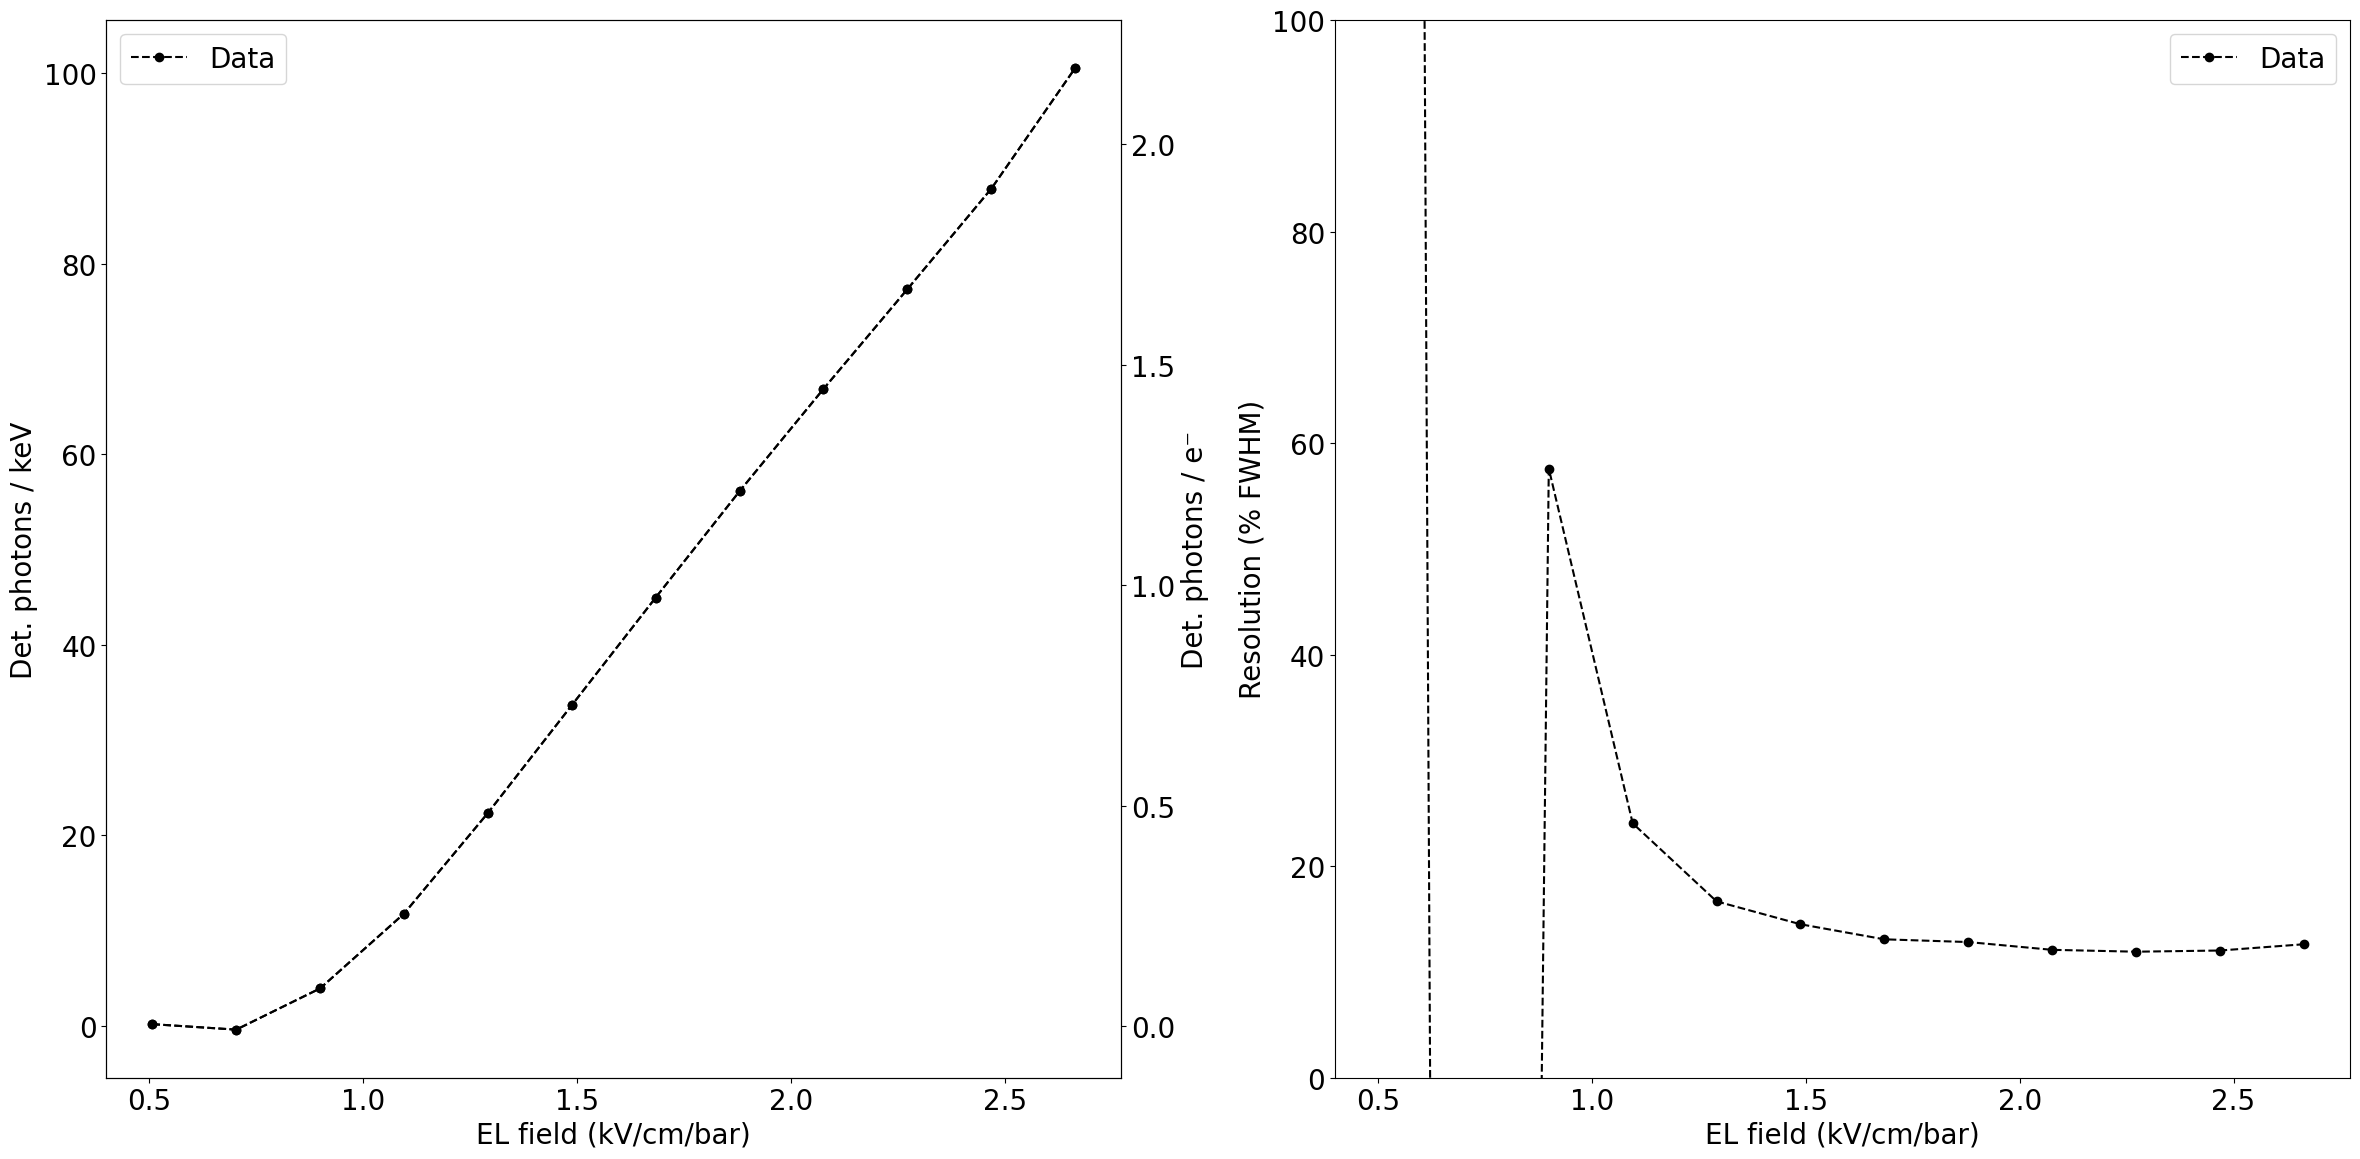

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

axes[0].errorbar(dst.el_volt/dst.pressure/dist, dst.photons_kev/dst.pressure, label='Data', marker='o',ls='--', c='k')
axes[1].errorbar(dst.el_volt/dst.pressure/dist, dst.resolution              , label='Data', marker='o',ls='--', c='k')
axt = axes[0].twinx()
axt.errorbar(dst.el_volt/dst.pressure/dist, dst.photons_kev/dst.pressure*(wi/1000), label='Data', marker='o',ls='--', c='k')
axes[1].set_ylim(0, 100)
#print("x1", dst.el_volt/dst.pressure/dist)
#print("y1", dst.photons_kev/dst.pressure)
#print("y2", dst.resolution)

for ax in axes:
    ax.set_xlabel('EL field (kV/cm/bar)')
    ax.legend()
    
axes[0].set_ylabel('Det. photons / keV')
axt    .set_ylabel('Det. photons / e⁻')
axes[1].set_ylabel('Resolution (% FWHM)')

fig.tight_layout()
#intrinsic_e   = np.array([get_intrinsic_resolution(eref*1000, fano, wi, mu/3, pmt_sigma) for mu in mus[:,0]])

In [195]:
#works
wi_keV = 21.61 / 1e3
config = ['R'+str(np.min(all_runs))+'-R'+str(np.max(all_runs))]
series = 0
print("conf is :", config[series])
#data_file = '/home/investigator/GapData/Electroluminescence/'+str(config[series])+'/dst.el_volt%dst.pressure%dist.txt'
#data_file_1 = '/home/investigator/GapData/Electroluminescence/'+str(config[series])+'/dst.photons_kev%dst.pressure.txt'
#data_file_2 = '/home/investigator/GapData/Electroluminescence/'+str(config[series])+'/dst.resolution.txt'

#np.savetxt(data_file, dst.el_volt/dst.pressure/dist, fmt="%.8f") #x1
#np.savetxt(data_file_1, dst.photons_kev/dst.pressure, fmt="%.8f") #y1
#np.savetxt(data_file_2, dst.resolution, fmt="%.8f") #y2
data_path_save = Path('/Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/'+str(config[series])+'_after_reprocess')

data_path_save.mkdir(exist_ok=True)

data_all = '/Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/'+str(config[series])+'_after_reprocess/data_plot_all_pmts.txt'
print(data_all)
data = np.column_stack((dst.el_volt/dst.pressure/dist, dst.photons_kev/dst.pressure, dst.photons_kev * wi_keV, dst.resolution))
np.savetxt(data_all, data, delimiter=" ", fmt="%.8f")




conf is : R2649-R2660
/Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2649-R2660_after_reprocess/data_plot_all_pmts.txt


data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2525-R2541_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2543-R2558_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2561-R2571_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2585-R2602_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2605-R2621_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2622-R2635_after_reprocess/data_plot_all_pmts.txt
data loaded are : /Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/R2649-R2660_after_repr

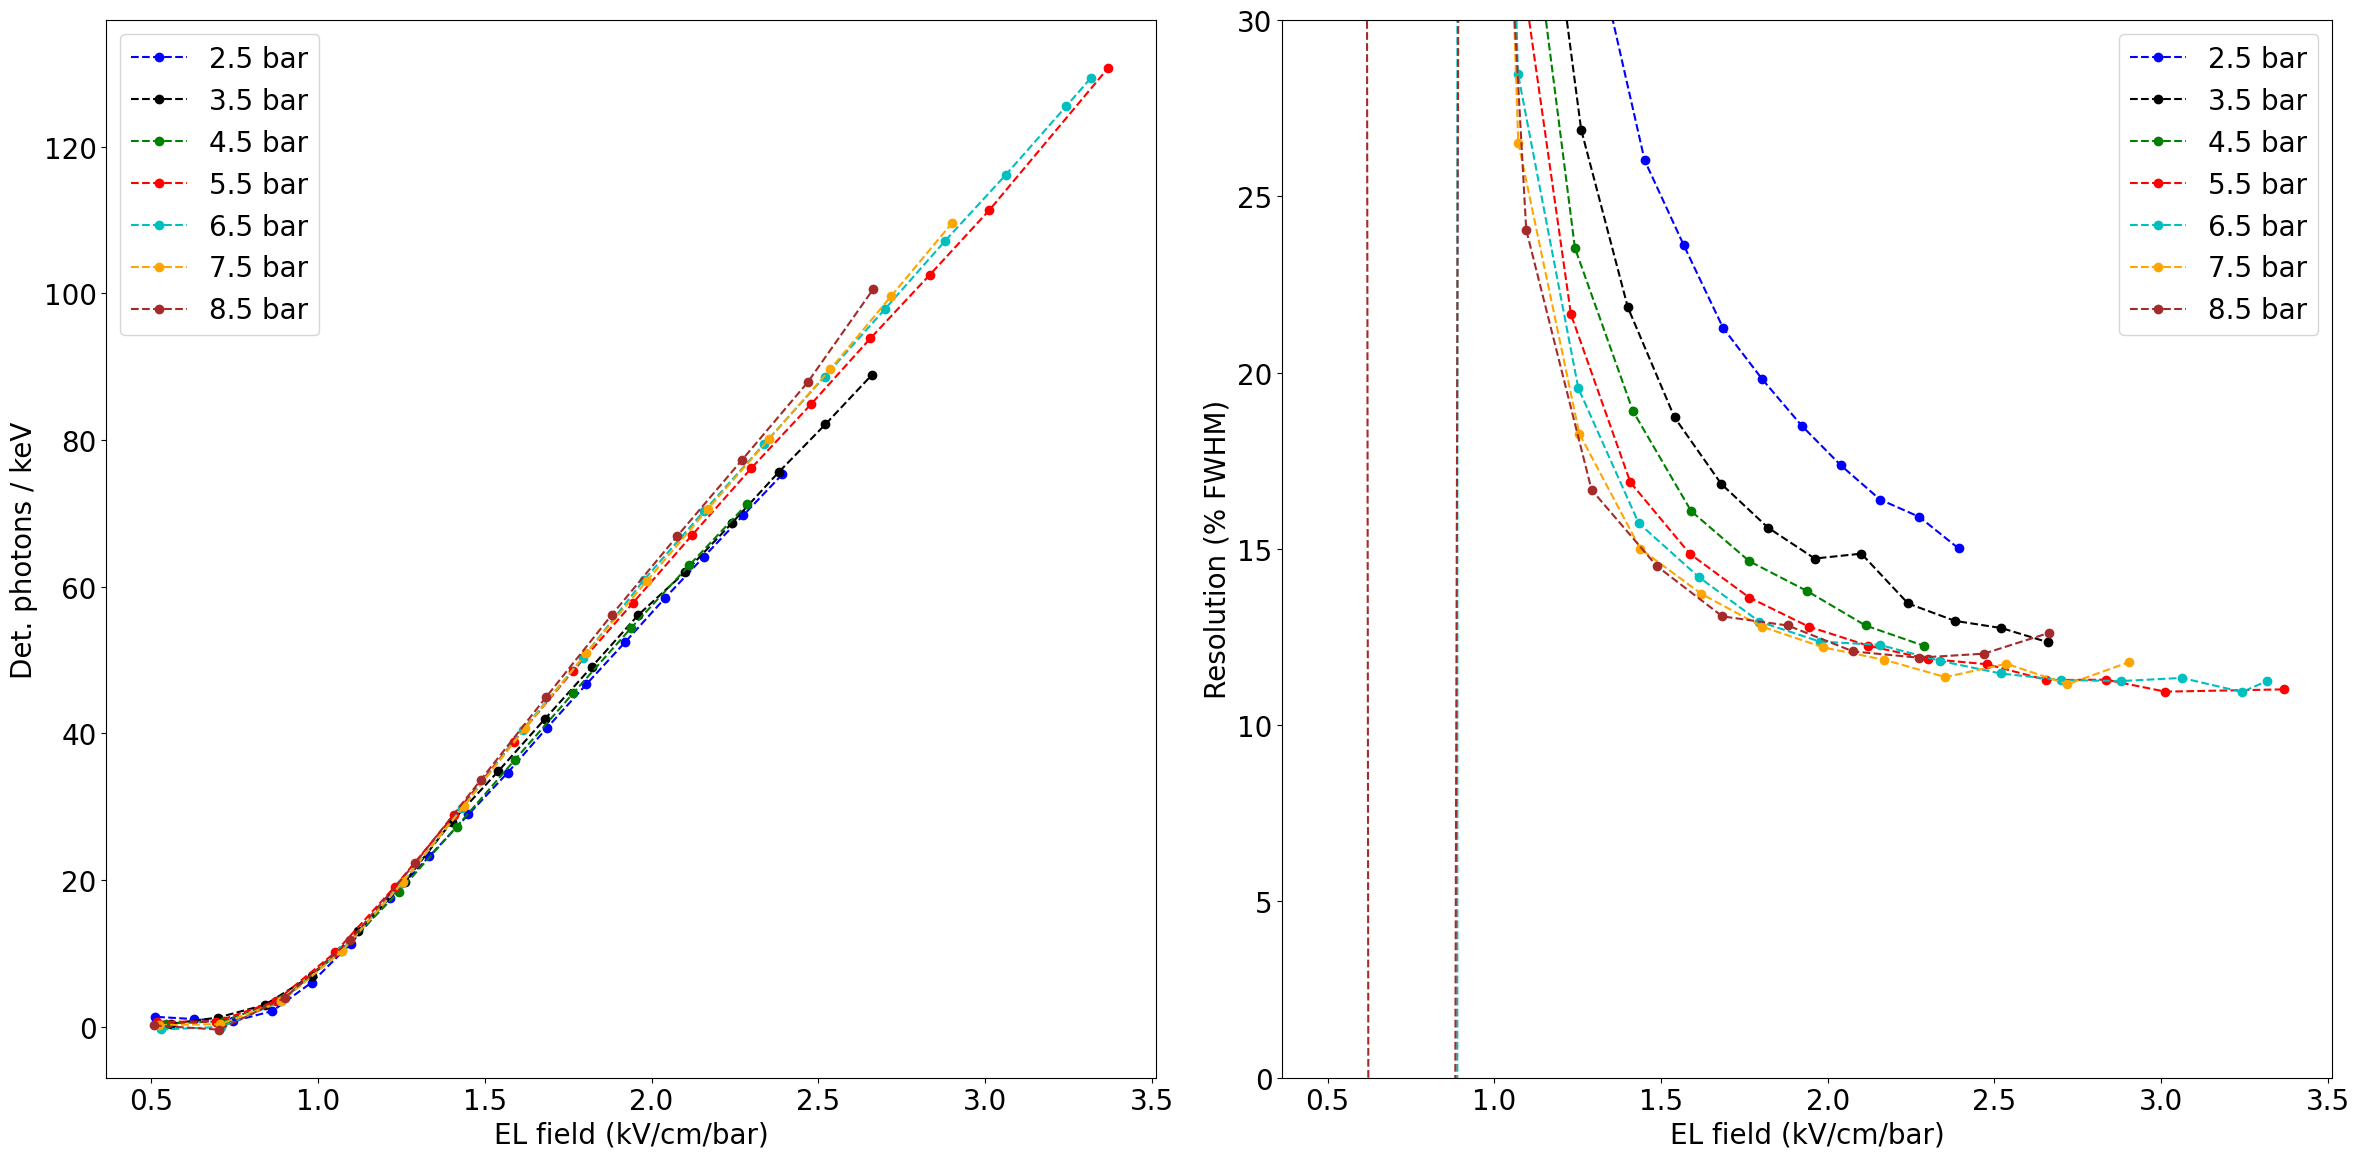

In [196]:
#works
#to compare plots

#config = ['R2525-R2541', 'R2543-R2558', 'R2561-R2571', 'R2585-R2602', 'R2605-R2621', 'R2622-R2635', 'R2649-R2660']
config = ['R2525-R2541_after_reprocess', 'R2543-R2558_after_reprocess', 'R2561-R2571_after_reprocess', 'R2585-R2602_after_reprocess', 'R2605-R2621_after_reprocess', 'R2622-R2635_after_reprocess', 'R2649-R2660_after_reprocess']

#config = ['R2649-R2660', 'R2649-R2660_after_reprocess']

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
colors = ['b', 'k', 'g', 'r', 'c', 'orange', 'brown']

legend = ['2.5 bar', '3.5 bar', '4.5 bar', '5.5 bar', '6.5 bar', '7.5 bar', '8.5 bar']

cpt = 0
for configs in config:
    #data_load = '/home/investigator/GapData/Electroluminescence/'+str(configs)+'/data_plot_S2.txt'
    data_load = '/Users/ldonneger/Desktop/PhD_Thesis2/GanESS/Presentations/Electroluminescence/'+str(configs)+'/data_plot_all_pmts.txt'

    print("data loaded are :", data_load)
    
    x1 = np.loadtxt(data_load)

    #print("x1[0] is :", x1[:,0])
    #print("dst.el_volt/dst.pressure/dist", dst.el_volt/dst.pressure/dist)

   
    axes[0].errorbar(x1[:, 0], x1[:, 1], label= str(legend[cpt]), marker='o',ls='--', c=colors[cpt])
    #axes[0].errorbar(x1[:, 0], x1[:, 1], label= str(pmt_on_off[cpt]), marker='o',ls='--', c=colors[cpt])



    axes[1].errorbar(x1[:, 0], x1[:, 2]              , label= str(legend[cpt]), marker='o',ls='--', c=colors[cpt])
    #axes[1].errorbar(x1[:, 0], x1[:, 2]              , label= str(pmt_on_off[cpt]), marker='o',ls='--', c=colors[cpt])

    #axt = axes[0].twinx()
    #axt.errorbar(x1[:, 0], x1[:, 1]*(wi/1000), label='5kV between gate-cathode- 5.57bar', marker='o',ls='--', c='k')

    for ax in axes:

        ax.set_xlabel('EL field (kV/cm/bar)')
        ax.legend()
    #axes[0].set_title('5kV of drift field - 5.46bar')
   # axes[0].set_title('Drift field : 5kV;  6.4bar; 2493-2497 & 2498-2502', pad=20)
    #axes[1].set_title('Drift Field = 5kV;  5.46bar;  Modification DAQ')

    axes[0].set_ylabel('Det. photons / keV')
    axt    .set_ylabel('Det. photons / e⁻')
    axes[1].set_ylabel('Resolution (% FWHM)')
    #axes[1].set_yscale('log')
    axes[1].set_ylim(0,30)
    fig.tight_layout()
    cpt = cpt + 1
    #intrinsic_e   = np.array([get_intrinsic_resolution(eref*1000, fano, wi, mu/3, pmt_sigma) for mu in mus[:,0]])

data loaded are : /Users/ldonneger/Desktop/GanESS/Presentations/Electroluminescence/['R2498-R2502']/data_plot_pmt0.txt


FileNotFoundError: /Users/ldonneger/Desktop/GanESS/Presentations/Electroluminescence/['R2498-R2502']/data_plot_pmt0.txt not found.

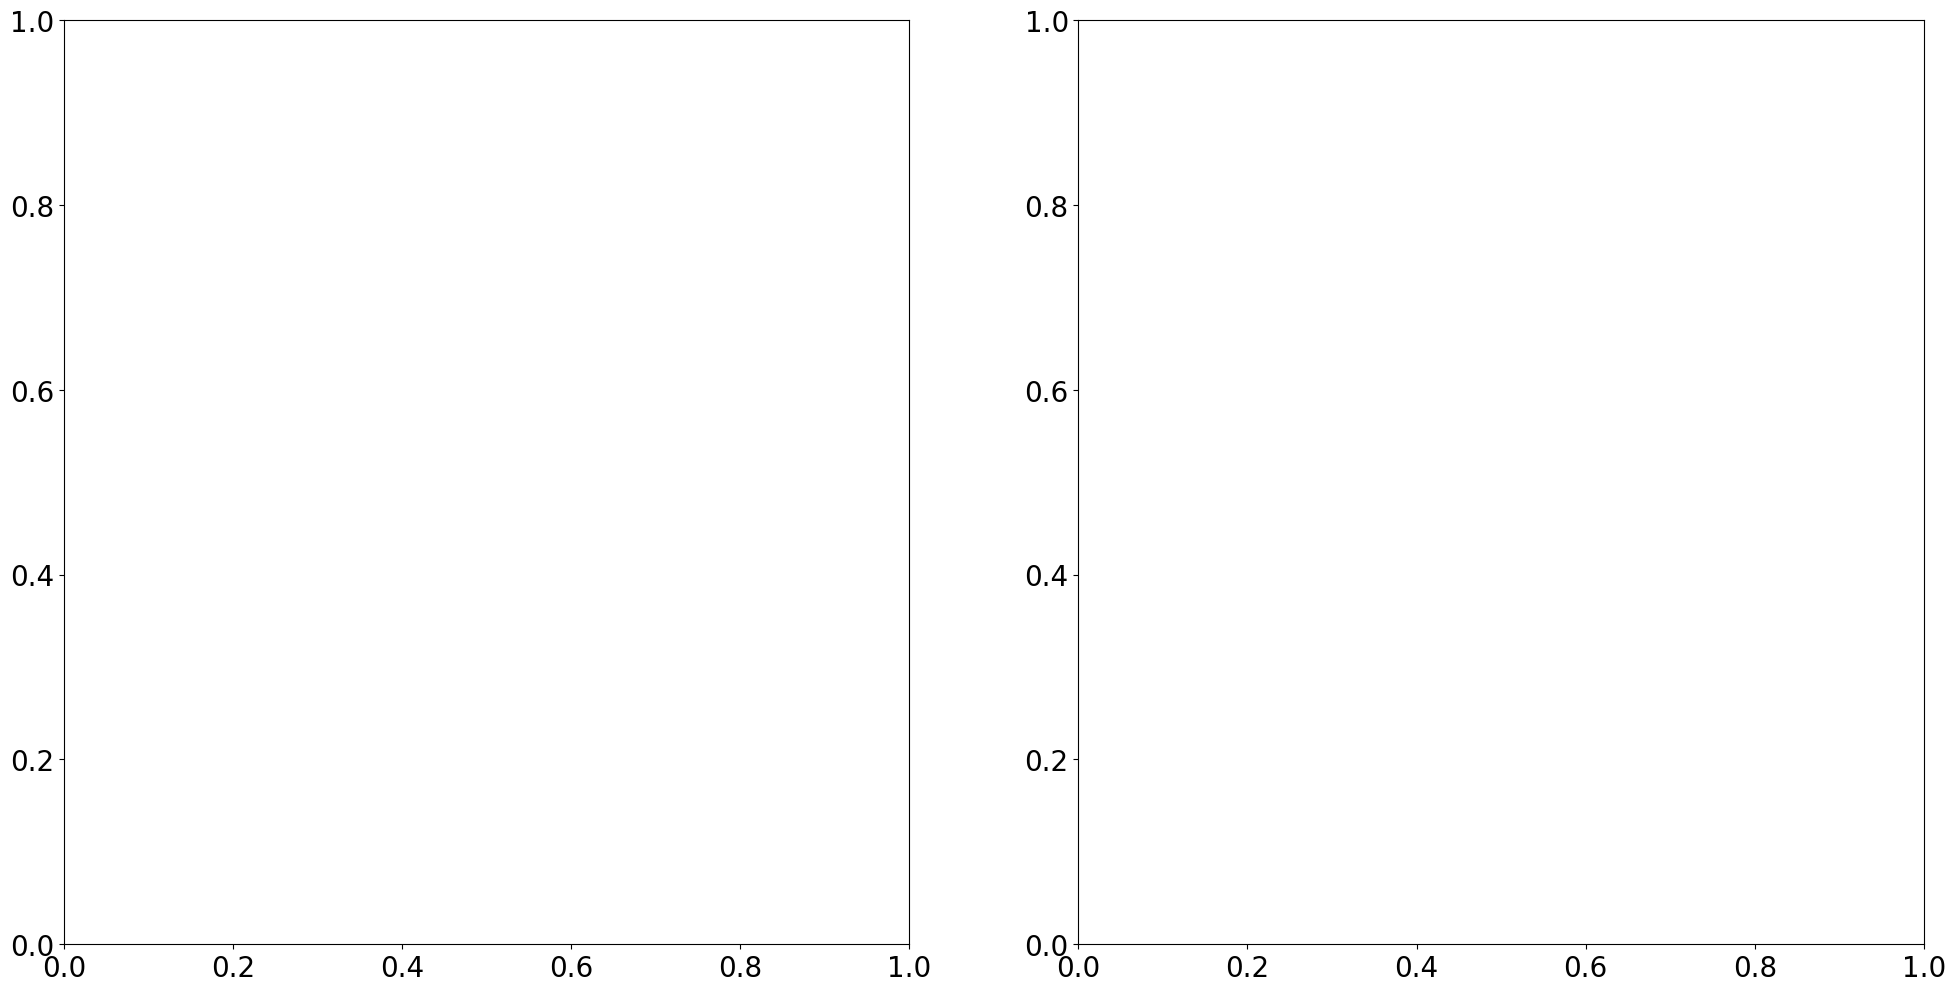

In [582]:
#works 
#to see all the pmts
#config = ['5.55bar_6kV', '5.57bar_5kV', '5.53bar_3kV', '5.53bar_2kV']
config = ['R2498-R2502']

pmt = [0, 1, 2, 3, 4, 5, 6]
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
colors = ['b', 'k', 'g', 'r','orange','purple','c']
el_drift = [12, 11.5, 11, 10.5]
#el_drift = [5]

pressures = [5.55, 5.57, 5.53, 5.53]
#pressures = [5.57]
light_mean = []
cpt = 0
for pmts in pmt:
    #data_load = '/home/investigator/GapData/Electroluminescence/'+str(configs)+'/data_plot_S2.txt'
    data_load = '/Users/ldonneger/Desktop/GanESS/Presentations/Electroluminescence/'+str(config)+'/data_plot_pmt'+str(pmts)+'.txt'

    print("data loaded are :", data_load)
    
    x1 = np.loadtxt(data_load)

    #print("x1[0] is :", x1[:,0])
    #print("dst.el_volt/dst.pressure/dist", dst.el_volt/dst.pressure/dist)

   

    axes[0].errorbar(x1[:, 0], x1[:, 1], label= 'PMT'+str(pmts), marker='o',ls='--', c=colors[cpt])
    light_mean.append(np.mean(x1[:, 1]))


    axes[1].errorbar(x1[:, 0], x1[:, 2]              , label='PMT'+str(pmts), marker='o',ls='--', c=colors[cpt])

    #axt = axes[0].twinx()
    #axt.errorbar(x1[:, 0], x1[:, 1]*(wi/1000), label='5kV between gate-cathode- 5.57bar', marker='o',ls='--', c='k')

    for ax in axes:

        ax.set_xlabel('EL field (kV/cm/bar)')
        ax.legend()

    axes[0].set_ylabel('Det. photons / keV')
    axt    .set_ylabel('Det. photons / e⁻')
    axes[1].set_ylabel('Resolution (% FWHM)')
    axes[0].set_title('Drift Field = 2kV;  5.53bar')
    axes[1].set_title('Drift Field = 2kV;  5.53bar')

    fig.tight_layout()
    cpt = cpt + 1
    
rank_light = np.stack((light_mean, pmt))
print(rank_light)
    #intrinsic_e   = np.array([get_intrinsic_resolution(eref*1000, fano, wi, mu/3, pmt_sigma) for mu in mus[:,0]])